# Casamento CATMAT ↔ e-Fisco: a história do pipeline e dos resultados

Este notebook é a **documentação narrativa** do trabalho de setembro de 2026 sobre o
casamento automático de itens entre o e-Fisco (Pernambuco, texto livre) e o CATMAT
(Governo Federal, rótulo estruturado): o que tentamos, o que falhou, o que funcionou
e por quê, na ordem em que aconteceu. Ele complementa o
[README](../README.md) (arquitetura) e o
[RESULTADOS-BIGDATA-PROFS.md](RESULTADOS-BIGDATA-PROFS.md) (todas as tabelas).

**Como usar.** As células rodam sobre os caches do repositório
(`cache/<dataset>/embeddings/`) e sobre as execuções congeladas em
`resultados/<dataset>/etapas/`. Não é preciso chave de API: nada aqui chama a LLM.
Execução completa: ~2 minutos em CPU, depois de uma primeira grade já rodada.

**A métrica.** Recall@3 (R@3): a fração das consultas e-Fisco cujo item CATMAT correto
está entre os três primeiros do ranking. É o que um curador consegue conferir de relance.
Reportamos também R@1 (o top-1 acertou) e MRR (a média de 1/posição do acerto).

In [1]:
import os, sys, json, re, warnings, logging
from pathlib import Path

BASE = Path.cwd()
if not (BASE / "catalogo_match").exists():
    BASE = BASE.parent
os.chdir(BASE)
sys.path.insert(0, str(BASE))
os.environ.setdefault("HF_HUB_DISABLE_PROGRESS_BARS", "1")
os.environ.setdefault("TRANSFORMERS_VERBOSITY", "error")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown

pd.set_option("display.width", 160)
pd.set_option("display.max_colwidth", 90)

from catalogo_match.config import ativar
from catalogo_match import avaliacao_modular as am, diagnostico as dg, taxonomia as tx, caracteristicas

for nome in ("", "catalogo_match", "sentence_transformers", "httpx", "huggingface_hub"):
    logging.getLogger(nome).setLevel(logging.WARNING)

ctx_cfg = ativar("bigdata_profs")
print(f"repositório: {BASE}")
print(f"dataset: {ctx_cfg.dataset.nome} | perfil: {ctx_cfg.perfil.nome}")

# --- estilo dos gráficos (paleta validada: um matiz de destaque + cinza de contexto) ---
SUPERFICIE, TINTA, TINTA_2, MUTED, GRADE, BASELINE = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
AZUL, LARANJA, AQUA = "#2a78d6", "#eb6834", "#1baf7a"          # slots categóricos 1-3
CINZA_CONTEXTO = "#c3c2b7"
RAMPA = ["#86b6ef", "#3987e5", "#184f95"]                      # ordinal, 3 passos
plt.rcParams.update({"font.family": "sans-serif", "font.size": 10, "figure.dpi": 110,
                     "axes.titlesize": 11, "axes.titleweight": "bold", "axes.titlelocation": "left"})

def estilo(ax, y_grid=True):
    ax.set_facecolor(SUPERFICIE); ax.figure.set_facecolor(SUPERFICIE)
    for lado in ("top", "right"): ax.spines[lado].set_visible(False)
    for lado in ("left", "bottom"): ax.spines[lado].set_color(BASELINE)
    ax.tick_params(colors=MUTED, length=0)
    if y_grid:
        ax.yaxis.grid(True, color=GRADE, linewidth=1); ax.set_axisbelow(True)
    ax.xaxis.grid(False)

def barras(rotulos, valores, destaque=(), titulo="", fmt="{:.1%}", ylim=None, largura=0.55, figsize=(7.2, 3.4), cores=None):
    fig, ax = plt.subplots(figsize=figsize)
    cores = cores or [AZUL if i in destaque else CINZA_CONTEXTO for i in range(len(valores))]
    ax.bar(range(len(valores)), valores, width=largura, color=cores, edgecolor=SUPERFICIE, linewidth=2)
    for i, v in enumerate(valores):
        ax.text(i, v, " " + fmt.format(v), ha="center", va="bottom", fontsize=9, color=TINTA)
    ax.set_xticks(range(len(valores))); ax.set_xticklabels(rotulos, color=TINTA_2)
    if ylim: ax.set_ylim(*ylim)
    ax.set_title(titulo); estilo(ax)
    ax.yaxis.set_major_formatter(matplotlib.ticker.PercentFormatter(1.0, decimals=0))
    plt.tight_layout(); plt.show()

def linhas(series, titulo="", xlabel="", ylabel="R@3", figsize=(7.2, 3.4), ref=None, ref_rotulo=""):
    fig, ax = plt.subplots(figsize=figsize)
    cores = [AZUL, LARANJA, AQUA]
    for (nome, xs, ys), cor in zip(series, cores):
        ax.plot(xs, ys, color=cor, linewidth=2, marker="o", markersize=6, markeredgecolor=SUPERFICIE, markeredgewidth=2, label=nome)
        k = int(np.argmax(ys)); ax.annotate(f"{ys[k]:.1%}", (xs[k], ys[k]), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=9, color=TINTA)
    if ref is not None:
        ax.axhline(ref, color=BASELINE, linewidth=1); ax.text(ax.get_xlim()[1], ref, " " + ref_rotulo, va="center", fontsize=8, color=MUTED)
    if len(series) > 1: ax.legend(frameon=False, fontsize=9, labelcolor=TINTA_2)
    ax.set_title(titulo); ax.set_xlabel(xlabel, color=TINTA_2); ax.set_ylabel(ylabel, color=TINTA_2); estilo(ax)
    ax.yaxis.set_major_formatter(matplotlib.ticker.PercentFormatter(1.0, decimals=0))
    plt.tight_layout(); plt.show()

ETAPAS = BASE / "resultados" / "bigdata_profs" / "etapas"
VARR = BASE / "resultados" / "bigdata_profs" / "varreduras"

def ranking(etapa):
    return pd.read_csv(ETAPAS / etapa / "ranking_combinacoes.csv").set_index("combinacao")

def stats(caminho):
    return json.loads(Path(caminho).read_text(encoding="utf-8"))

repositório: C:\Users\Educação\mmh
dataset: bigdata_profs | perfil: compras_publicas


## 1. O ponto de partida: um dataset que parece o MMH de longe

Tínhamos uma receita que funcionava no MMH (Material Médico-Hospitalar): o bi-encoder
**E5** para a similaridade semântica, e dois reordenadores do top-20, a **medida tipada**
(valor + unidade convertidos) e o **GraphRAG offline** (cobertura de entidades). R@3 de 67,5%
sem blocking, 60,7% no pipeline completo.

Chegou o dataset `bigdata_profs`: 1.392 pares "ouro", vindos de mineração em larga escala
(`big_data`) e de revisão por profissionais de saúde (`profs_saude`). De longe parece o MMH;
de perto é multi-domínio.

In [2]:
df = ctx_cfg.dataset.ler()
print(f"{len(df)} pares | {df.codigo_efisco.nunique()} consultas e-Fisco | {df.codigo_catmat.nunique()} itens CATMAT")
print("\norigem:", df.origem.value_counts().to_dict())
pdm = df.item_catmat.str.split(",").str[0].str.strip()
print(f"PDMs distintos no catálogo: {pdm.nunique()}  (o MMH tem ~200 em 1.054 itens)")
grupos = df.grupo_efisco.replace("", "(sem grupo)").value_counts()
print(f"\ngrupos do e-Fisco: {len(grupos)}; o médico-hospitalar tem {grupos.iloc[0]/len(df):.0%}, o resto se espalha:")
display(grupos.head(8).rename("pares").to_frame())
exemplos = df.sample(3, random_state=7)[["item_efisco", "item_catmat"]]
exemplos["item_efisco"] = exemplos.item_efisco.str[:88]; exemplos["item_catmat"] = exemplos.item_catmat.str[:88]
display(exemplos.reset_index(drop=True))

1392 pares | 1375 consultas e-Fisco | 1297 itens CATMAT

origem: {'big_data': 1150, 'profs_saude': 242}
PDMs distintos no catálogo: 724  (o MMH tem ~200 em 1.054 itens)

grupos do e-Fisco: 46; o médico-hospitalar tem 72%, o resto se espalha:


,pares
grupo_efisco,
"EQUIPAMENTOS E ARTIGOS DE USO MEDICO, ODONTOLOGICO , HOSPITALAR E LABORATORIAL",996
"EQUIPAMENTOS E MATERIAIS PARA EXPERIENCIA EM LABORATORIO ESCOLAR, RECREACAO E DESPORTO",37
MOBILIARIOS EM GERAL,34
ARTIGOS E UTENSILIOS DE ESCRITORIOS,31
ARTIGOS DE HIGIENE,28
GENEROS ALIMENTICIOS,27
"EQUIPAMENTOS PARA REFEITORIO, COPA E COZINHA",22
INFORMATICA,21


,item_efisco,item_catmat
0,"ISOSSORBIDA, DINITRATO - CONCENTRACAO/DOSAGEM 10 MG,FORMA FARMACEUTICA COMPRIMIDO,VIA DE","ISOSSORBIDA, PRINCÍPIO ATIVO: SAL DINITRATO , DOSAGEM: 10 MG"
1,"CADEIRA PARA OTORRINO - AUTOMATIZADA, COM MOTORE ISENTO DE OLEO, EM ACO, PINTURA EM EPOX","CADEIRA CLÍNICA, APLICAÇÃO: OFTALMO/OTORRINO/RADIOLOGIA , MATERIAL: ESTRUTURA EM AÇO , A"
2,"DILATADOR - DILATADOR TIPO AMPLATZ,COMPONETES DILATADORES POLIURETANO COM CALIBRES DE 6","DILATADOR, USO: NEFROSTOMIA PERCUTÂNEA , MATERIAL: POLÍMERO , DIÂMETRO: TAMANHOS DIVERSO"


Rodamos a receita do MMH sem mexer em nada (perfil `mmh`, extrator como estava). É a
**etapa 01** em `resultados/bigdata_profs/etapas/`.

In [3]:
r01 = ranking("01_baseline_perfil_mmh")
linhas_base = ["nada + tfidf + nada", "basico + tfidf + nada", "nada + e5 + nada", "basico + e5 + nada",
               "nada + e5 + unidades_graphrag", "nada + e5 + medidas_graphrag", "basico + e5 + medidas_graphrag", "nada + e5 + pdm"]
display(r01.loc[linhas_base, ["mrr", "recall_at_1", "recall_at_3", "recall_at_10"]].round(3))

,mrr,recall_at_1,recall_at_3,recall_at_10
combinacao,,,,
nada + tfidf + nada,0.554,0.437,0.627,0.788
basico + tfidf + nada,0.651,0.535,0.726,0.876
nada + e5 + nada,0.675,0.569,0.740,0.882
basico + e5 + nada,0.669,0.562,0.742,0.869
nada + e5 + unidades_graphrag,0.680,0.570,0.754,0.889
nada + e5 + medidas_graphrag,0.702,0.601,0.768,0.895
basico + e5 + medidas_graphrag,0.693,0.585,0.778,0.882
nada + e5 + pdm,0.595,0.468,0.674,0.854


Parecia razoável: 74% com o E5 puro, 77,7% com a melhor combinação do MMH. Mas repare que a
normalização `basico` vale **+10 pontos** no TF-IDF (no MMH valia +5), e que a melhor
combinação do MMH ganha só +2,8 pontos sobre o E5 (no MMH ganhava +7,4). O corpus era
outro. Antes de tentar qualquer coisa, olhamos **onde** o R@3 se perdia.

## 2. O diagnóstico: o erro é de família, não de detalhe

`catalogo_match.diagnostico` responde, consulta a consulta, em que posição o item correto
ficou. A célula abaixo reexecuta o E5 puro (embeddings em cache) e classifica as posições.

,n,%
faixa,,
1,773,56.2
2-3,248,18.0
4-10,174,12.7
11-20,57,4.1
>20,123,8.9


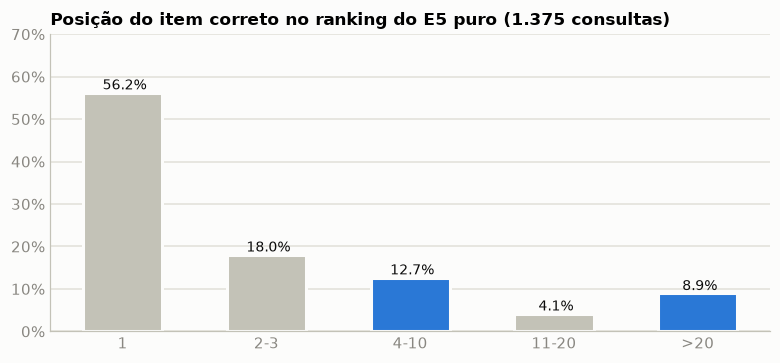

In [4]:
corpus = am.carregar_corpus()
ctx = {"peso_pos": am.PESO_POS_PADRAO, "peso_medidas": am.PESO_MEDIDAS_PADRAO,
       "tolerancia_medidas": caracteristicas.TOLERANCIA_PADRAO, "k_cross": am.K_CROSS_RERANK, "api_key": ""}
_, idx_e5, _ = dg.executar_combinacao(corpus, "basico", "e5", "nada", ctx, am.K_CANDIDATOS)
pos_e5 = dg.posicoes(corpus, idx_e5)
tab_e5 = dg.tabela_consultas(corpus, idx_e5, pos_e5, am.K_CANDIDATOS)
faixas = dg.resumo_faixas(tab_e5, am.K_CANDIDATOS)
display(faixas)
barras(faixas.index.tolist(), (faixas["n"] / len(tab_e5)).tolist(), destaque=(2, 4),
       titulo="Posição do item correto no ranking do E5 puro (1.375 consultas)", ylim=(0, 0.7))

Dois números importam. **14% das consultas** têm o correto entre a 4ª e a 10ª posição: é o
que um reordenador do top-20 pode consertar. E **8% estão fora do top-20**: nenhum
reordenador alcança; só a recuperação alcança. Mas o achado decisivo é **quem** ocupa o
topo no lugar do correto.

In [5]:
falhas = tab_e5[tab_e5.faixa == "4-10"]
print(f"falhas recuperáveis (correto em 4-10): {len(falhas)}")
print(f"top-1 com o MESMO PDM do correto: {falhas.mesmo_pdm_top1_correto.mean():.0%}   (no MMH: 67%)")
print("\nexemplos: o E5 casa o vocabulário e erra a família")
for _, r in falhas.head(3).iterrows():
    print(f"\n  CONSULTA : {r.item_efisco[:110]}")
    print(f"  TOP-1    : {r.top1_catmat[:110]}")
    print(f"  CORRETO  : {r.correto_catmat[:110]}")
display(dg.resumo_faixas(tab_e5, am.K_CANDIDATOS, "origem"))

falhas recuperáveis (correto em 4-10): 174
top-1 com o MESMO PDM do correto: 48%   (no MMH: 67%)

exemplos: o E5 casa o vocabulário e erra a família

  CONSULTA : KIT PARA DETECCAO DE SANGUE OCULTO - DETERMINACAO DA PRESENCA DE SANGUE OCULTO EM AMOSTRAS DE FEZES, COM DISPO
  TOP-1    : REAGENTE PARA DIAGNÓSTICO CLÍNICO 4, TIPO: CONJUNTO COMPLETO , TIPO DE ANÁLISE: QUALITATIVO DE ROTAVÍRUS E ADE
  CORRETO  : REAGENTE PARA DIAGNÓSTICO CLÍNICO 7, TIPO*: CONJUNTO COMPLETO , TIPO DE ANÁLISE*: QUANTITATIVO CALPROTECTINA F

  CONSULTA : FIO DE SUTURA POLIESTER TRANCADO COM CERA - EM FILAMENTOS DE POLIESTER TRANCADO, TRANCADO COM COM 2 AGULHAS AT
  TOP-1    : FIO DE SUTURA AGULHADO, MATERIAL FIO: POLIÉSTER C/ ALGODÃO AZUL , MODELO FIO: MULTIFILAMENTAR , DIÂMETRO FIO: 
  CORRETO  : FIO DE SUTURA AGULHADO, MATERIAL FIO: POLIÉSTER VERDE , MODELO FIO: MULTIFILAMENTAR , COMPONENTE FIO: C/ REVES

  CONSULTA : LIXEIRA HOSPITALAR - EM POLIPROPILENO,COM TAMPA ACIONADA POR PEDAL COM EIXO DE FERRO , COM 

faixa,1,2-3,4-10,11-20,>20,n,R@3,teto(top-K)
origem,,,,,,,,
big_data,668,201,125,42,112,1148,0.757,0.902
profs_saude,105,47,49,15,11,227,0.670,0.952


No MMH, o intruso era um irmão da mesma família com um atributo diferente (67% mesmo PDM);
aqui, só 41%. `CAMA BELICHE` vira `COLCHA CAMA`, `QUEBRA-CABEÇA EM MADEIRA` vira `TÁBUA DE
MADEIRA`. O embedding casa o vocabulário e erra a **classe**. Isso é o que a taxonomia dos
catálogos e o léxico exato sabem, e o embedding não. As consultas revisadas por profissionais
(`profs_saude`) são as mais difíceis: 66,5% contra 75,5%.

## 3. Aposta 1, a ontologia: as duas taxonomias como sinal

Os dois catálogos **já são** taxonomias: o e-Fisco em grupo > classe, o CATMAT em grupo >
classe > PDM. E 85% dos pares do gabarito repetem a combinação (classe e-Fisco, classe CATMAT)
de algum outro par. `catalogo_match/taxonomia.py` alinha as duas hierarquias e estima
P(classe CATMAT | classe e-Fisco) nos vínculos conhecidos, em **leave-one-out**: a consulta
avaliada nunca contribui para a própria estimativa. Quando a classe é desconhecida, cai
para o nível de grupo.

In [6]:
al = tx.alinhamento_historico(corpus.consultas, corpus.catalogo, corpus.gold)
M = tx.matriz_compatibilidade(al)
cods = corpus.catalogo["codigo_catmat"].tolist(); idx_c = {c: j for j, c in enumerate(cods)}
corretos = np.array([M[i, idx_c[g]] for i, ce in enumerate(corpus.consultas["codigo_efisco"])
                     for g in corpus.gold.get(ce, ()) if g in idx_c])
rng = np.random.default_rng(0)
aleat = M[rng.integers(0, M.shape[0], 5000), rng.integers(0, M.shape[1], 5000)]
print(f"compatibilidade média do par CORRETO   : {corretos.mean():.2f}  (> 0 em {(corretos > 0).mean():.0%})")
print(f"compatibilidade média de um par ALEATÓRIO: {aleat.mean():.2f}  (> 0 em {(aleat > 0).mean():.0%})")
print(f"consultas cuja classe não tem outro vínculo (só grupo): {tx.diagnostico_cobertura(al, corpus.gold, corpus.consultas, corpus.catalogo)['classe_sem_historico_loo']}")

compatibilidade média do par CORRETO   : 0.62  (> 0 em 92%)
compatibilidade média de um par ALEATÓRIO: 0.23  (> 0 em 71%)
consultas cuja classe não tem outro vínculo (só grupo): 133


O sinal é bom. Então somamos ao score do E5, com o peso que servia à medida no MMH (0,05),
e o R@3 **piorou**. Varremos o peso (`catalogo_match.varredura`):

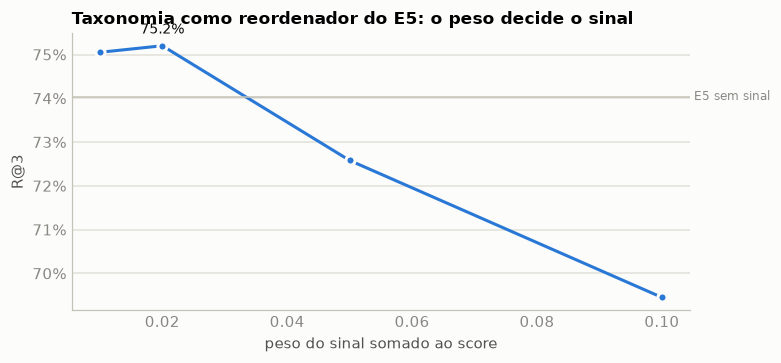

In [7]:
sw = pd.read_csv(VARR / "nada+e5+taxonomia_medidas_taxonomia__peso_medidas_taxonomia_peso_grupo_taxonomia_min_obs.csv")
s = sw[(sw.pos == "taxonomia") & (sw.taxonomia_peso_grupo == 0.3) & (sw.taxonomia_min_obs == 2)].sort_values("peso_medidas")
r_e5 = float(r01.loc["nada + e5 + nada", "recall_at_3"])
linhas([("taxonomia (aditivo)", s.peso_medidas.tolist(), s.recall_at_3.tolist())],
       titulo="Taxonomia como reordenador do E5: o peso decide o sinal", xlabel="peso do sinal somado ao score",
       ref=r_e5, ref_rotulo="E5 sem sinal")

**Lição 1, e ela volta em todas as outras: a escala em que um sinal entra decide mais do que o
sinal.** Com peso 0,05 a taxonomia tira 1,4 pontos; com 0,02, dá 1,2. O sinal é denso (71%
dos pares têm compatibilidade > 0 pelo grupo), e precisa entrar como **desempate**, não
como voto. A distância típica entre o 1º e o 10º colocado do E5 é de ~0,10; qualquer bônus
maior do que isso vira "ordene pelo bônus, desempate pelo E5".

## 4. Aposta 2, o GraphRAG: o mesmo grafo vale coisas diferentes em lugares diferentes

O GraphRAG offline do repositório constrói um grafo de conhecimento item ↔ entidade
(PDM, valores de atributo, tokens) com comunidades Louvain. Testamos o grafo em **três
posições** da grade: como pré-processador (expande a consulta com entidades vizinhas), como
fonte de recuperação (a busca local vira um ranking, fundido ao E5) e como pós-processador
(cobertura das entidades da consulta pelo candidato, ponderada pelo IDF de cada entidade).

In [8]:
r04, r06 = ranking("04_modulos_novos_compras_publicas"), ranking("06_pre_processadores")
sw1 = pd.read_csv(VARR / "basico+e5+medidas_graphrag_idf_aditivo_taxonomia_medidas_taxonomia_medidas_graphrag_idf_medidas_graphrag_idf_taxonomia__peso_medidas_peso_rel_taxonomia.csv")
gr_adit = float(sw1[(sw1.pos == "graphrag_idf_aditivo") & (sw1.peso_medidas == 0.05)].recall_at_3.iloc[0])
linhas_gr = [
    ("referência", "basico + e5, sem grafo", r04.loc["basico + e5 + nada", "recall_at_3"]),
    ("pré-processador", "graphrag: 6 termos vizinhos + rótulo da comunidade", r06.loc["graphrag + e5 + nada", "recall_at_3"]),
    ("pré-processador", "graphrag_leve: 3 termos", r06.loc["graphrag_leve + e5 + nada", "recall_at_3"]),
    ("recuperação", "e5_kg: RRF de E5 com a busca local do KG", r04.loc["basico + e5_kg + nada", "recall_at_3"]),
    ("pós, convexo 0,25", "graphrag (peso fixo por entidade)", r04.loc["basico + e5 + graphrag", "recall_at_3"] if "basico + e5 + graphrag" in r04.index else np.nan),
    ("pós, convexo 0,25", "graphrag_idf (IDF por entidade)", r04.loc["basico + e5 + graphrag_idf", "recall_at_3"]),
    ("pós, aditivo 0,05", "graphrag_idf_aditivo", gr_adit),
    ("pós, aditivo", "medidas + graphrag_idf", r04.loc["basico + e5 + medidas_graphrag_idf", "recall_at_3"]),
]
tab_gr = pd.DataFrame(linhas_gr, columns=["posição", "módulo", "R@3"]).dropna()
tab_gr["R@3"] = tab_gr["R@3"].map("{:.1%}".format)
display(tab_gr.set_index("posição"))

,módulo,R@3
posição,,
referência,"basico + e5, sem grafo",74.2%
pré-processador,graphrag: 6 termos vizinhos + rótulo da comunidade,69.2%
pré-processador,graphrag_leve: 3 termos,71.6%
recuperação,e5_kg: RRF de E5 com a busca local do KG,67.4%
"pós, convexo 0,25",graphrag_idf (IDF por entidade),72.7%
"pós, aditivo 0,05",graphrag_idf_aditivo,76.9%
"pós, aditivo",medidas + graphrag_idf,78.9%


Como **expansor de consulta**, o grafo custa 5 pontos: os termos que ele injeta são
vocabulário de família (`DESCARTAVEL`, `ESTERIL`, `EMBALAGEM INDIVIDUAL`) e diluem o que
distingue o item. Como **fonte de recuperação**, piora ainda mais: um grafo de entidades é um
índice invertido ponderado, não uma medida de semelhança. Como **pós-processador** ele ajuda,
desde que (de novo a lição 1) entre somado com peso pequeno: a mistura convexa com peso 0,25,
a dos pós-processadores publicados no MMH, deixa o bônus dominar e piora em qualquer variante.
E pesar cada entidade pelo IDF vale +1 ponto: `ORTOFTALALDEIDO` decide, `DESCARTAVEL` não.

## 5. A virada: juntar o léxico exato ao semântico

O diagnóstico dizia que os intrusos eram lexicalmente parecidos e de outra família, e que 8%
dos corretos estavam fora do top-20. A hipótese: uma fonte com **erros diferentes** dos do
E5, o casamento exato de termos (TF-IDF), casaria `CALPROTECTINA`, `25 L` e `TRANPARENTE`
(com erro de grafia) onde o embedding falha. A célula reexecuta a grade para quatro
processadores sobre o texto normalizado, com e sem os sinais simbólicos calibrados
(`combinado_calibrado`).

,R@3 sem pós,R@3 + combinado_calibrado
processador,,
e5,74.2%,79.8%
e5_tfidf,78.8%,76.2%
e5_tfidf_lin,80.9%,82.5%
e5_tfidf_char_lin,81.9%,84.2%


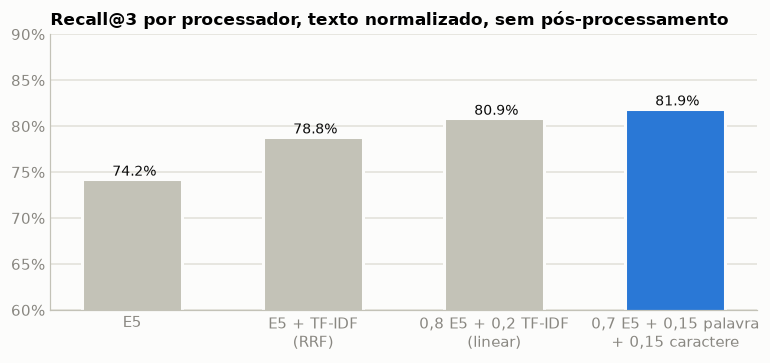

In [9]:
combos = am.executar_grade(corpus, ["basico"], ["e5", "e5_tfidf", "e5_tfidf_lin", "e5_tfidf_char_lin"],
                           ["nada", "combinado_calibrado"], ctx=dict(ctx))
tab_f = pd.DataFrame([{"processador": c["proc"], "pós": c["pos"], **c["metricas"]} for c in combos if c["metricas"]])
piv = tab_f.pivot(index="processador", columns="pós", values="recall_at_3").loc[["e5", "e5_tfidf", "e5_tfidf_lin", "e5_tfidf_char_lin"], ["nada", "combinado_calibrado"]]
piv.columns = ["R@3 sem pós", "R@3 + combinado_calibrado"]
display(piv.style.format("{:.1%}"))
rot = {"e5": "E5", "e5_tfidf": "E5 + TF-IDF\n(RRF)", "e5_tfidf_lin": "0,8 E5 + 0,2 TF-IDF\n(linear)", "e5_tfidf_char_lin": "0,7 E5 + 0,15 palavra\n+ 0,15 caractere"}
barras([rot[p] for p in piv.index], piv["R@3 sem pós"].tolist(), destaque=(3,),
       titulo="Recall@3 por processador, texto normalizado, sem pós-processamento", ylim=(0.6, 0.9))

**+7,6 pontos de uma vez, sem nenhum modelo novo.** A forma de fundir importa (lição 1, de
novo): o RRF, a receita clássica, recupera bem sozinho, mas iguala fontes desiguais e produz um
score numa escala (~1/60 por posição) em que os reordenadores calibrados para cosseno quebram.
A **soma linear de cossenos** mantém a escala do E5: o TF-IDF entra como evidência léxica que o
E5 pondera, não como voto igual. E os n-gramas de **caracteres** casam grafia e abreviação sem
léxico nenhum. O peso do léxico é robusto: de 0,1 a 0,3 o R@3 varia dentro de 1 ponto.

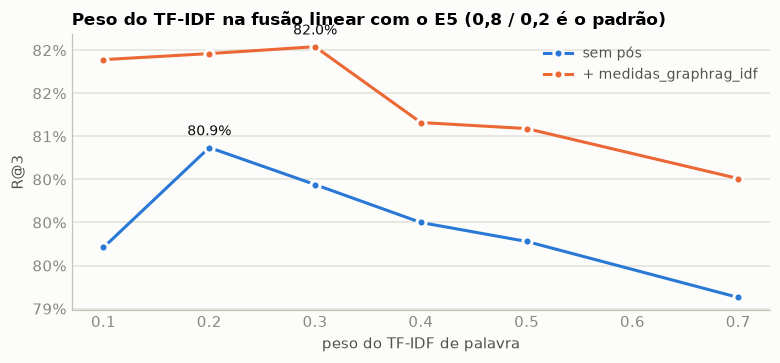

In [10]:
swf = pd.read_csv(VARR / "basico+e5_tfidf_lin+nada_medidas_graphrag_idf_medidas_graphrag_idf_taxonomia__peso_fusao_tfidf.csv")
s0 = swf[swf.pos == "nada"].sort_values("peso_fusao_tfidf")
s1 = swf[swf.pos == "medidas_graphrag_idf"].sort_values("peso_fusao_tfidf")
linhas([("sem pós", s0.peso_fusao_tfidf.tolist(), s0.recall_at_3.tolist()),
        ("+ medidas_graphrag_idf", s1.peso_fusao_tfidf.tolist(), s1.recall_at_3.tolist())],
       titulo="Peso do TF-IDF na fusão linear com o E5 (0,8 / 0,2 é o padrão)", xlabel="peso do TF-IDF de palavra")

## 6. Somando tudo: os sinais calibrados e a grade final

Sobre a fusão, os três sinais simbólicos, medida tipada, GraphRAG-IDF e taxonomia, entram
somados ao score com peso 0,05 e pesos relativos 0,6 / 1,0 / 0,3 (`combinado_calibrado`). Os
pesos saíram de varreduras, e uma varredura em **duas metades disjuntas** das consultas
confirmou que a ordem das combinações se mantém nas duas: o ganho é do sinal, não do ajuste.

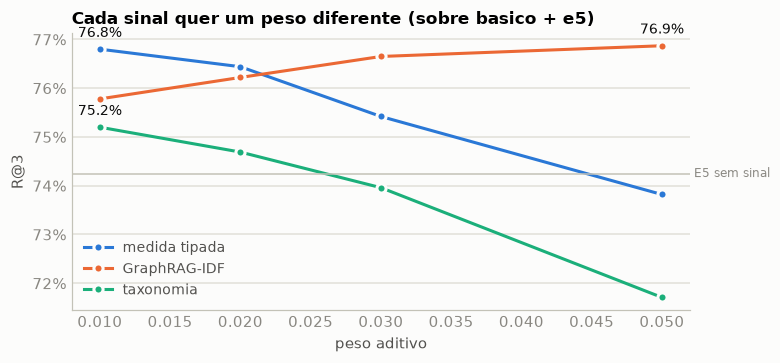

R@3 no total e nas duas metades (p0 = consultas pares, p1 = ímpares), sobre e5_tfidf_char_lin:


,pos,peso_medidas,recall_at_3,recall_at_3_p0,recall_at_3_p1
0,combinado_calibrado,0.03,0.8429,0.8328,0.8530
1,combinado_calibrado,0.05,0.8415,0.8285,0.8544
2,combinado_calibrado,0.08,0.8305,0.8140,0.8472
3,medidas_graphrag_idf,0.03,0.8305,0.8125,0.8486
4,medidas_graphrag_idf,0.05,0.8364,0.8256,0.8472
5,medidas_graphrag_idf,0.08,0.8342,0.8183,0.8501
6,nada,0.03,0.8189,0.8023,0.8355
7,nada,0.05,0.8189,0.8023,0.8355
8,nada,0.08,0.8189,0.8023,0.8355


In [11]:
for pos_ in ("medidas", "graphrag_idf_aditivo", "taxonomia"):
    pass
s_med = sw1[(sw1.pos == "medidas") & (sw1.peso_rel_taxonomia == 0.3)].sort_values("peso_medidas")
s_gr = sw1[(sw1.pos == "graphrag_idf_aditivo") & (sw1.peso_rel_taxonomia == 0.3)].sort_values("peso_medidas")
s_tx = sw1[(sw1.pos == "taxonomia") & (sw1.peso_rel_taxonomia == 1.0)].sort_values("peso_medidas")
linhas([("medida tipada", s_med.peso_medidas.tolist(), s_med.recall_at_3.tolist()),
        ("GraphRAG-IDF", s_gr.peso_medidas.tolist(), s_gr.recall_at_3.tolist()),
        ("taxonomia", s_tx.peso_medidas.tolist(), s_tx.recall_at_3.tolist())],
       titulo="Cada sinal quer um peso diferente (sobre basico + e5)", xlabel="peso aditivo",
       ref=float(r04.loc["basico + e5 + nada", "recall_at_3"]), ref_rotulo="E5 sem sinal")
swp = pd.read_csv(VARR / "basico+e5_tfidf_char_lin+nada_medidas_graphrag_idf_medidas_graphrag_idf_taxonomia_combinado_calibrado__peso_medidas.csv")
cols = [c for c in swp.columns if c.startswith("recall_at_3")]
tab_p = swp[swp.pos.isin(["nada", "medidas_graphrag_idf", "combinado_calibrado"])].pivot(index="pos", columns="peso_medidas", values=cols)
print("R@3 no total e nas duas metades (p0 = consultas pares, p1 = ímpares), sobre e5_tfidf_char_lin:")
display(swp[swp.pos.isin(["nada", "medidas_graphrag_idf", "combinado_calibrado"])][["pos", "peso_medidas"] + cols].round(4).sort_values(["pos", "peso_medidas"]).reset_index(drop=True))

A medida quer peso menor do que no MMH (sozinha, com o peso 0,05 do MMH, ela **tira** meio
ponto aqui: 724 PDMs, a medida raramente é o que distingue o item), o grafo quer o peso
inteiro e a taxonomia entra como desempate. A grade final (`etapas/08_grade_final/`, 70
combinações) é esta:

,mrr,recall_at_1,recall_at_3,recall_at_10
combinacao,,,,
basico + e5_tfidf_char_lin + combinado_calibrado,0.763,0.668,0.842,0.923
basico + e5_tfidf_char_lin + medidas_graphrag_idf,0.758,0.661,0.836,0.922
basico + e5_tfidf_char_lin + medidas_graphrag,0.757,0.660,0.834,0.920
basico + e5_char_lin + combinado_calibrado,0.755,0.659,0.832,0.923
basico + e5_char_lin + medidas_graphrag_idf,0.755,0.659,0.830,0.921
nada + e5_char_lin + medidas_graphrag,0.755,0.662,0.829,0.918


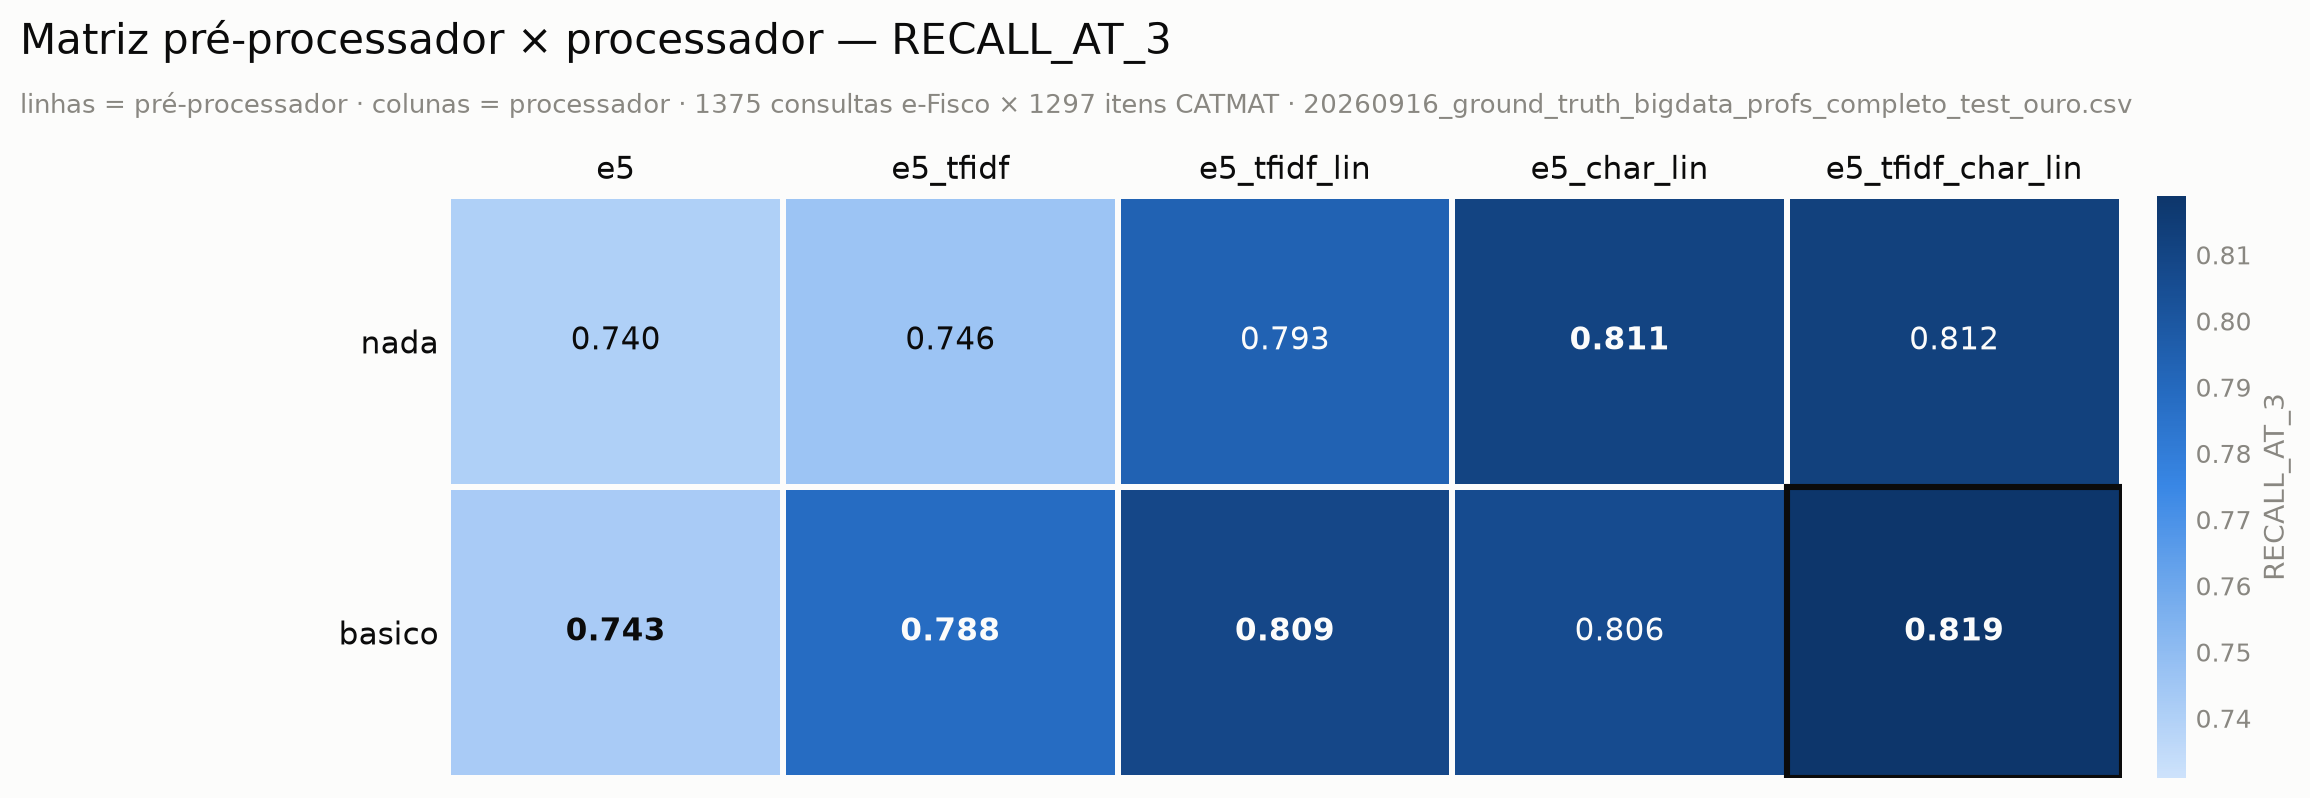

In [12]:
r08 = ranking("08_grade_final")
display(r08[["mrr", "recall_at_1", "recall_at_3", "recall_at_10"]].head(6).round(3))
display(Image(filename=str(ETAPAS / "08_grade_final" / "matriz_modular.png"), width=760))

De **74,0% para 84,2%** de R@3 na grade, MRR de 0,675 para 0,763. Dois complementos que não
aparecem na tabela: o **perfil** `compras_publicas`, que herda o do MMH e acrescenta massa,
dose, concentração e tensão (é o que faz `500 MG` e `0,9%` serem lidos), e a correção do
**extrator de medidas**, que lia `210,00X86,00X162,00CM` como um objeto de 620 mm.

In [13]:
from catalogo_match.config import perfil_ativo
p = perfil_ativo()
for t in ["CAMA BELICHE EM ACO MEDINDO 210,00X86,00X162,00CM", "AGULHA 18G X 1 1/2\"",
          "DIPIRONA SOLUCAO ORAL 500 MG/ML FRASCO 10 ML", "SORO FISIOLOGICO 0,9% 500 ML", "LAMPADA LED 9 W 220 V"]:
    print(f"{t:<52} -> {caracteristicas.extrair(t, p)}")
perfis = {}
for nome in ("base", "mmh", "compras_publicas"):
    c = pd.read_csv(VARR / f"nada+e5_tfidf_char_lin+nada_medidas_medidas_graphrag_idf_combinado_calibrado__padrao__perfil-{nome}.csv").set_index("pos")
    perfis[nome] = {"sem pós": c.loc["nada", "recall_at_3"], "combinado_calibrado": c.loc["combinado_calibrado", "recall_at_3"]}
print("\nR@3 por perfil (pré nada, e5_tfidf_char_lin):")
display(pd.DataFrame(perfis).T.style.format("{:.1%}"))

CAMA BELICHE EM ACO MEDINDO 210,00X86,00X162,00CM    -> {'MM': {2100.0, 1620.0, 860.0}}
AGULHA 18G X 1 1/2"                                  -> {'MM': {38.1}, 'G_GAUGE': {18.0}}
DIPIRONA SOLUCAO ORAL 500 MG/ML FRASCO 10 ML         -> {'MG_ML': {500.0}, 'ML': {10.0}}
SORO FISIOLOGICO 0,9% 500 ML                         -> {'ML': {500.0}, 'PCT': {0.9}}
LAMPADA LED 9 W 220 V                                -> {'W': {9.0}, 'V': {220.0}}

R@3 por perfil (pré nada, e5_tfidf_char_lin):


,sem pós,combinado_calibrado
base,81.2%,82.0%
mmh,81.2%,82.3%
compras_publicas,81.2%,82.6%


O mesmo par processador + pós-processador, sem ajuste nenhum, no **MMH**:

In [14]:
VM = BASE / "resultados" / "mmh" / "varreduras"
m_e5 = pd.read_csv(VM / "basico+e5+nada_medidas_medidas_graphrag_medidas_graphrag_idf_combinado_calibrado__padrao.csv").set_index("pos")
m_fu = pd.read_csv(VM / "basico+e5_tfidf_char_lin+nada_medidas_medidas_graphrag_medidas_graphrag_idf_combinado_calibrado__padrao.csv").set_index("pos")
tab_m = pd.DataFrame({
    "e5 + nada": m_e5.loc["nada", ["mrr", "recall_at_1", "recall_at_3"]],
    "e5 + medidas_graphrag (publicado: 0,604 / 48,3 / 67,5)": m_e5.loc["medidas_graphrag", ["mrr", "recall_at_1", "recall_at_3"]],
    "e5_tfidf_char_lin + medidas_graphrag": m_fu.loc["medidas_graphrag", ["mrr", "recall_at_1", "recall_at_3"]],
}).T.round(3)
display(tab_m)

,mrr,recall_at_1,recall_at_3
e5 + nada,0.539,0.410,0.607
"e5 + medidas_graphrag (publicado: 0,604 / 48,3 / 67,5)",0.607,0.486,0.681
e5_tfidf_char_lin + medidas_graphrag,0.683,0.567,0.770


## 7. Para dentro do pipeline completo, com a LLM

A grade mede módulos isolados, sem blocking. O pipeline das fases [0]–[9] é o sistema de
verdade: rede semântica, extração de atributos por LLM, blocking, ontologia OWL com
reasoner, matcher, GraphRAG, confiança, explicabilidade. Levamos o que a grade mediu para
dentro dele:

```
[0] fontes → [1] rede semântica (âncora de PDM) → [2] extração LLM + SHACL
 → [3] blocking (PDM, subsunção, família, classe + top-50 pela FUSÃO)      teto: 96,8%
 → [4] ontologia OWL + Pellet (equivalenteA / veto)
 → [5] matcher: estágio 1 = fusão dentro do bloco, top-20
 → [5b] sinais: medida, GraphRAG-IDF, taxonomia (+ ontologia) somados ao score
 → [6] adjudicação por LLM → [8] confiança → avaliação com ABLAÇÃO por camada
```

A **ablação por camada** foi a ferramenta central desta parte: o mesmo top-20 de cada
consulta reordenado pelo score de cada fase acumulada, numa só execução. Rodamos quatro
configurações com a chave da OpenAI (`gpt-4o-mini`):

- **A**: cross-encoder ligado, LLM adjudica o par top-1 com contexto de vizinhos TF-IDF;
- **B**: sem cross-encoder, LLM adjudica com o índice **Microsoft GraphRAG** (2 h de indexação);
- **C**: sem API nenhuma (regex e votação);
- **D**: LLM na extração, sem cross-encoder, sem adjudicação.

In [15]:
execs = {"A: LLM, cross, adj. par (ctx TF-IDF)": "09_pipeline_llm_sem_indice_ms",
         "B: LLM, sem cross, adj. par (índice MS)": "10_pipeline_llm_indice_ms_sem_cross",
         "C: sem LLM, sem cross": "11_pipeline_sem_llm_sem_cross",
         "D: LLM na [2], sem cross, sem adj.": "12_pipeline_llm_sem_cross_sem_adjudicacao"}
camadas = ["cosseno E5 (só o bi-encoder)", "fusão E5+TF-IDF (estágio 1)", "+ cross-encoder (estágio 2)",
           "+ sinais simbólicos (fase 5b)", "+ GraphRAG (fase 6)", "score final (fase 8)"]
tab_ab = {}
for rotulo, etapa in execs.items():
    s = stats(ETAPAS / etapa / "stats_pipeline.json")
    ab = s["avaliacao"]["ablacoes"]
    tab_ab[rotulo] = {c: ab[c]["recall_at_3"] for c in camadas if c in ab}
tab_ab = pd.DataFrame(tab_ab).reindex(camadas)
print("R@3 por camada acumulada (recall do blocking, teto: 96,8%):")
display(tab_ab.style.format("{:.1%}", na_rep="—"))

R@3 por camada acumulada (recall do blocking, teto: 96,8%):


,"A: LLM, cross, adj. par (ctx TF-IDF)","B: LLM, sem cross, adj. par (índice MS)","C: sem LLM, sem cross","D: LLM na [2], sem cross, sem adj."
cosseno E5 (só o bi-encoder),75.1%,75.1%,75.1%,75.1%
fusão E5+TF-IDF (estágio 1),81.9%,81.9%,81.9%,81.9%
+ cross-encoder (estágio 2),80.2%,81.9%,81.9%,81.9%
+ sinais simbólicos (fase 5b),82.1%,84.1%,83.6%,84.1%
+ GraphRAG (fase 6),79.9%,79.3%,83.3%,84.0%
score final (fase 8),80.4%,79.1%,82.5%,82.3%


Três coisas incômodas apareceram. O **cross-encoder** tira 1,7 ponto e custa 33 minutos. A
**adjudicação por LLM de um par isolado** ("este e-Fisco é este CATMAT?") tira 2,2 pontos com
contexto TF-IDF e **4,8** com o índice Microsoft GraphRAG, que levou quase três horas e mil
chamadas para construir e consultar. E a **ontologia como fatia de 0,35 do score final** tira
1,8 ponto: um único `equivalenteA` (1,0 contra 0,3 do `incompleto`) valia mais que todo o
espalhamento da similaridade e puxava pares errados ao topo. A LLM na **extração** (fase [2])
foi o único lugar em que ela ajudou até aqui: +0,5 ponto, via atributos que entram no grafo
como entidades tipadas.

## 8. A finalização: perguntar diferente à LLM

A LLM não era o problema; a pergunta era. Julgar um par isolado leva o modelo a ser
conservador e a rebaixar itens certos cuja especificação está incompleta no texto. Trocamos a
pergunta: em vez de "este par é igual?", **"qual destes cinco é o item?"**. Para as 500
consultas de menor margem entre o 1º e o 2º candidato, a LLM vê os cinco melhores de uma vez,
cada um com seu score, a dedução da ontologia e as medidas que satisfaz, e dá uma nota a cada um.
A nota entra com peso `p` no `score_graphrag`, e este pesa 0,2 no score final: com `p = 0,1` a
nota vale **2% do score**, um desempate. Junto, movemos a ontologia para a escala dos outros
sinais e desligamos o cross-encoder e o veto (que acertava e errava na mesma proporção).

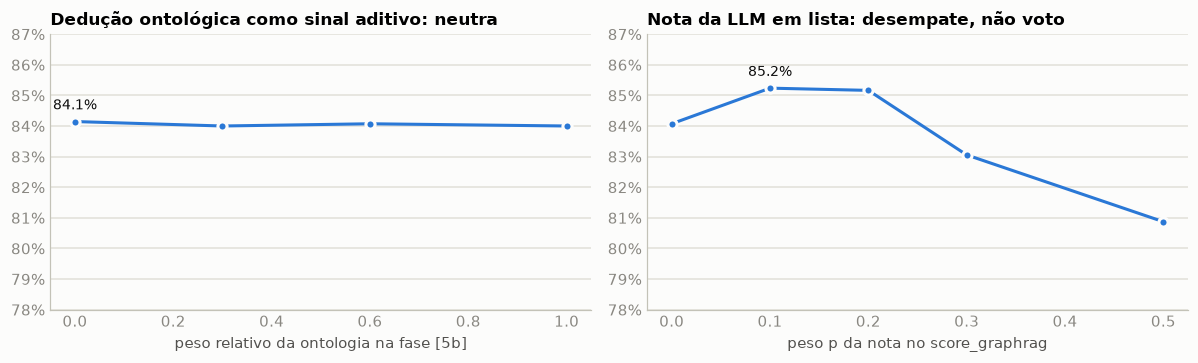

In [16]:
ont = {w: stats(ETAPAS / "16_sinal_ontologia" / f"peso_rel_{w}" / "stats_pipeline.json")["avaliacao"]["recall_at_3"] for w in ("0", "0.3", "0.6", "1.0")}
adj = {"0": stats(ETAPAS / "16_sinal_ontologia" / "peso_rel_0.6" / "stats_pipeline.json")["avaliacao"]["recall_at_3"]}
adj.update({w: stats(ETAPAS / "18_peso_adjudicacao" / f"peso_{w}" / "stats_pipeline.json")["avaliacao"]["recall_at_3"] for w in ("0.1", "0.2", "0.3", "0.5")})
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
for ax, (titulo, d, xl) in zip(axes, [("Dedução ontológica como sinal aditivo: neutra", ont, "peso relativo da ontologia na fase [5b]"),
                                       ("Nota da LLM em lista: desempate, não voto", adj, "peso p da nota no score_graphrag")]):
    xs = [float(k) for k in d]; ys = list(d.values())
    ax.plot(xs, ys, color=AZUL, linewidth=2, marker="o", markersize=6, markeredgecolor=SUPERFICIE, markeredgewidth=2)
    k = int(np.argmax(ys)); ax.annotate(f"{ys[k]:.1%}", (xs[k], ys[k]), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=9, color=TINTA)
    ax.set_title(titulo); ax.set_xlabel(xl, color=TINTA_2); ax.set_ylim(0.78, 0.87); estilo(ax)
    ax.yaxis.set_major_formatter(matplotlib.ticker.PercentFormatter(1.0, decimals=0))
plt.tight_layout(); plt.show()

Com `p = 0,5`, as mesmas notas **pioram** o R@3 em 3 pontos: as notas baixas dos candidatos não
escolhidos empurram o correto, quando não é o escolhido, para fora do top-3. Com `p = 0,1`, é
a primeira vez que a LLM melhora o ranking neste sistema. É o terceiro sinal em que a forma de
combinar decide mais que o sinal: medida, taxonomia, agora a LLM.

A execução **padrão** do pipeline (sem nenhuma flag) é a etapa 17:

,mrr,recall_at_1,recall_at_3,recall_at_10
cosseno E5 (só o bi-encoder),0.676,56.4%,75.1%,88.7%
fusão E5+TF-IDF (estágio 1),0.743,64.4%,81.9%,91.8%
+ cross-encoder (estágio 2),0.743,64.4%,81.9%,91.8%
+ sinais simbólicos (fase 5b),0.766,67.2%,84.0%,92.3%
+ adjudicação (fase 6) = score final,0.783,69.9%,85.2%,92.3%


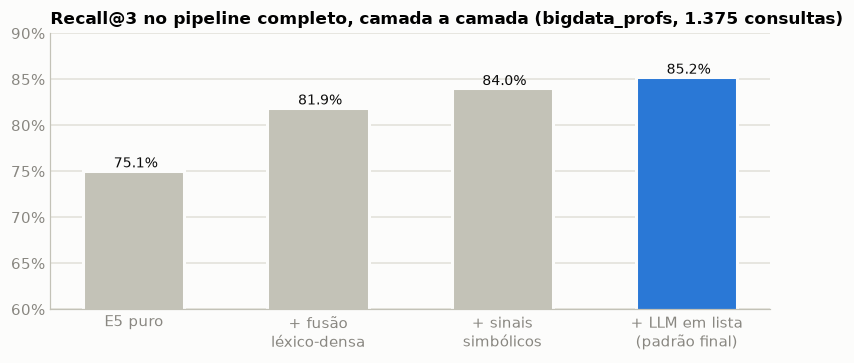

In [17]:
s17 = stats(ETAPAS / "17_pipeline_final_lista" / "stats_pipeline.json")
ab = s17["avaliacao"]["ablacoes"]
tab17 = pd.DataFrame(ab).T[["mrr", "recall_at_1", "recall_at_3", "recall_at_10"]]
display(tab17.style.format({"mrr": "{:.3f}", "recall_at_1": "{:.1%}", "recall_at_3": "{:.1%}", "recall_at_10": "{:.1%}"}))
etapas_hist = [("E5 puro", ab["cosseno E5 (só o bi-encoder)"]["recall_at_3"]),
               ("+ fusão\nléxico-densa", ab["fusão E5+TF-IDF (estágio 1)"]["recall_at_3"]),
               ("+ sinais\nsimbólicos", ab["+ sinais simbólicos (fase 5b)"]["recall_at_3"]),
               ("+ LLM em lista\n(padrão final)", ab["+ adjudicação (fase 6) = score final"]["recall_at_3"])]
barras([e[0] for e in etapas_hist], [e[1] for e in etapas_hist], destaque=(3,),
       titulo="Recall@3 no pipeline completo, camada a camada (bigdata_profs, 1.375 consultas)", ylim=(0.6, 0.9))

A **confiança** também mudou. Os limiares absolutos do MMH (score ≥ 0,75 = Alta) colocavam 81%
das consultas em "Média" e não diziam nada. A margem entre o 1º e o 2º candidato diz: a
avaliação mede a precisão de cada faixa contra o gabarito.

,consultas,% das consultas,P@1,R@3
Alta,473,34.4%,96.2%,98.3%
Média,303,22.0%,76.2%,91.1%
Baixa,599,43.6%,45.9%,72.0%


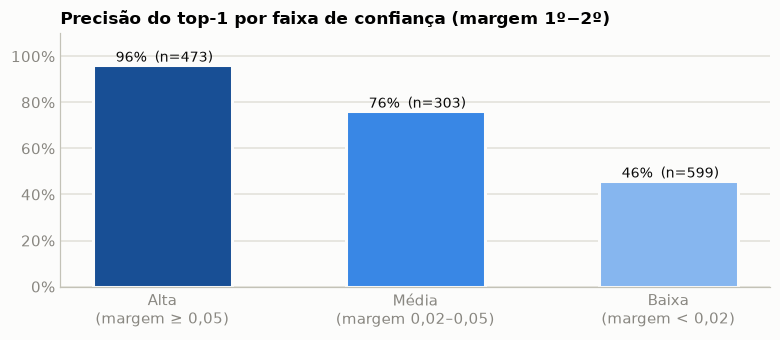

erros do top-1 por faixa: {'Alta': 18, 'Média': 72, 'Baixa': 324}  → a faixa Baixa concentra 78% dos erros


In [18]:
pc = s17["avaliacao"]["por_confianca"]
faixas_c = ["Alta", "Média", "Baixa"]
tab_c = pd.DataFrame({f: {"consultas": pc[f]["n"], "% das consultas": pc[f]["fracao"], "P@1": pc[f]["precisao_at_1"], "R@3": pc[f]["recall_at_3"]} for f in faixas_c}).T
display(tab_c.style.format({"consultas": "{:.0f}", "% das consultas": "{:.1%}", "P@1": "{:.1%}", "R@3": "{:.1%}"}))
fig, ax = plt.subplots(figsize=(7.2, 3.2))
vals = [pc[f]["precisao_at_1"] for f in faixas_c]
ax.bar(range(3), vals, width=0.55, color=RAMPA[::-1], edgecolor=SUPERFICIE, linewidth=2)
for i, f in enumerate(faixas_c):
    ax.text(i, vals[i], f" {vals[i]:.0%}  (n={pc[f]['n']})", ha="center", va="bottom", fontsize=9, color=TINTA)
ax.set_xticks(range(3)); ax.set_xticklabels([f"{f}\n(margem {'≥ 0,05' if f == 'Alta' else ('0,02–0,05' if f == 'Média' else '< 0,02')})" for f in faixas_c], color=TINTA_2)
ax.set_ylim(0, 1.1); ax.set_title("Precisão do top-1 por faixa de confiança (margem 1º−2º)"); estilo(ax)
ax.yaxis.set_major_formatter(matplotlib.ticker.PercentFormatter(1.0, decimals=0)); plt.tight_layout(); plt.show()
erros = {f: round(pc[f]["n"] * (1 - pc[f]["precisao_at_1"])) for f in faixas_c}
print(f"erros do top-1 por faixa: {erros}  → a faixa Baixa concentra {erros['Baixa'] / sum(erros.values()):.0%} dos erros")

A faixa **Alta** cobre um terço das consultas com 96% de acerto no top-1: é o que pode ir para
o catálogo sem revisão. A **Baixa** concentra 78% dos erros em 44% das consultas: é onde a
curadoria deve olhar. O mesmo pipeline, com os padrões novos, no MMH:

In [19]:
VME = BASE / "resultados" / "mmh" / "etapas"
m_final = stats(VME / "pipeline_final_llm" / "stats_pipeline.json")["avaliacao"]
m_semllm = stats(VME / "pipeline_fusao_sem_llm_sem_cross" / "stats_pipeline.json")["avaliacao"]
tab_mmh = pd.DataFrame({
    "publicado (RESULTADOS.md): LLM, E5 puro, cross, composição antiga": {"mrr": 0.553, "recall_at_1": 0.439, "recall_at_3": 0.607, "recall_blocking": 0.982},
    "padrão final, sem LLM (2 min)": {k: m_semllm[k] for k in ("mrr", "recall_at_1", "recall_at_3", "recall_blocking")},
    "padrão final, com LLM (9 min)": {k: m_final[k] for k in ("mrr", "recall_at_1", "recall_at_3", "recall_blocking")},
}).T
display(tab_mmh.style.format({"mrr": "{:.3f}", "recall_at_1": "{:.1%}", "recall_at_3": "{:.1%}", "recall_blocking": "{:.1%}"}))

,mrr,recall_at_1,recall_at_3,recall_blocking
"publicado (RESULTADOS.md): LLM, E5 puro, cross, composição antiga",0.553,43.9%,60.7%,98.2%
"padrão final, sem LLM (2 min)",0.649,52.3%,73.3%,98.8%
"padrão final, com LLM (9 min)",0.677,56.6%,75.2%,98.8%


## 9. O que fica


1. Juntar o léxico exato ao semântico foi o maior ganho: a fusão linear E5 + TF-IDF de
   palavra e de caractere vale +7,6 pontos de R@3, e generaliza para o MMH.
2. Todo sinal simbólico entra como **desempate**, na escala certa, nunca como voto. A medida, a
   taxonomia, o grafo, a ontologia e a própria LLM ajudam com peso pequeno e atrapalham com
   peso grande.
3. A LLM ajuda quando a pergunta é **relativa** ("qual destes é o item?") e a resposta é um
   desempate; julgando pares isolados, ela rebaixa acertos.

**O que foi testado e descartado**, com números, para ninguém refazer: RRF (escala
incompatível), GraphRAG como expansor de consulta (−5 pp), grafo como score de recuperação,
cross-encoder mMARCO (−1,7 pp), adjudicação par a par (−2,2 a −4,8 pp), ontologia como fatia
convexa (−1,8 pp), veto (neutro), índice Microsoft GraphRAG como expansor (empata com a
normalização básica, a uma chamada por consulta).

**Números finais.**

| | E5 puro | grade (melhor cadeia) | pipeline padrão |
|---|---|---|---|
| `bigdata_profs`, R@3 | 74,0% | 84,2% | **85,2%** (R@1 69,9%, MRR 0,783) |
| MMH, R@3 | 61,4% | 77,0% | **75,2%** (publicado: 60,7%) |

**Como reproduzir.**

```bash
python -m catalogo_match.pipeline --dataset bigdata_profs            # padrão: 85,2%, ~5 min com cache
python -m catalogo_match.pipeline --dataset bigdata_profs --sem-llm  # sem chave: 82,5%, ~3 min
python -m catalogo_match.avaliacao_modular --dataset bigdata_profs --metrica recall_at_3
python -m catalogo_match.diagnostico --dataset bigdata_profs --pre basico --proc e5 --pos nada \
    --contra basico,e5_tfidf_char_lin,combinado_calibrado
```

**Onde está cada coisa.** Arquitetura e uso no [README](../README.md); tabelas completas e
leituras em [RESULTADOS-BIGDATA-PROFS.md](RESULTADOS-BIGDATA-PROFS.md); resultados do MMH em
[RESULTADOS.md](../RESULTADOS.md); cada execução congelada em
`resultados/bigdata_profs/etapas/NN_*/` (índice em `LEIA-ME.md`); como rodar em outro corpus
em [NOVO-DATASET.md](NOVO-DATASET.md).